In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 1. Load the datasets
print("Loading datasets...")
fg_df = pd.read_csv('fear_greed_index.csv')
hist_df = pd.read_csv('historical_data.csv')

# 2. Basic Audit: Rows, Columns, Missing Values, and Duplicates
print("\n--- Data Audit ---")
print(f"Fear & Greed Index: {fg_df.shape[0]} rows, {fg_df.shape[1]} columns")
print(f"Historical Data: {hist_df.shape[0]} rows, {hist_df.shape[1]} columns")

print(f"\nMissing Values in Fear & Greed: {fg_df.isnull().sum().sum()}")
print(f"Missing Values in Historical Data: {hist_df.isnull().sum().sum()}")

print(f"\nDuplicate Rows in Fear & Greed: {fg_df.duplicated().sum()}")
print(f"Duplicate Rows in Historical Data: {hist_df.duplicated().sum()}")

# 3. Standardize Dates
print("\n--- Standardizing Dates ---")
# Fear & Greed is already 'YYYY-MM-DD', just ensure it's a datetime object
fg_df['date'] = pd.to_datetime(fg_df['date'])

# Historical data uses 'DD-MM-YYYY HH:MM' in 'Timestamp IST'
# We will parse it and create a clean 'date' column to match the Fear/Greed data
hist_df['Datetime IST'] = pd.to_datetime(hist_df['Timestamp IST'], format='%d-%m-%Y %H:%M')
hist_df['date'] = hist_df['Datetime IST'].dt.normalize() # Keeps only the date part

print("Date conversion successful. Here are the date ranges:")
print(f"Fear & Greed ranges from: {fg_df['date'].min().date()} to {fg_df['date'].max().date()}")
print(f"Historical Data ranges from: {hist_df['date'].min().date()} to {hist_df['date'].max().date()}")

Loading datasets...

--- Data Audit ---
Fear & Greed Index: 2644 rows, 4 columns
Historical Data: 211224 rows, 16 columns

Missing Values in Fear & Greed: 0
Missing Values in Historical Data: 0

Duplicate Rows in Fear & Greed: 0
Duplicate Rows in Historical Data: 0

--- Standardizing Dates ---
Date conversion successful. Here are the date ranges:
Fear & Greed ranges from: 2018-02-01 to 2025-05-02
Historical Data ranges from: 2023-05-01 to 2025-05-01


In [2]:
# 1. Merge sentiment data into the historical trades dataset
print("Merging datasets...")
# We only need the date, value, and classification from the Fear & Greed data
fg_subset = fg_df[['date', 'value', 'classification']].rename(columns={
    'value': 'fg_value',
    'classification': 'fg_sentiment'
})

# Inner join ensures we only keep trades that have a corresponding sentiment score
merged_df = pd.merge(hist_df, fg_subset, on='date', how='inner')

# 2. Pre-calculate win/loss flags for the Win Rate calculation
# Note: Trades with exactly 0 Closed PnL are usually opening a position, so we ignore them for win rate.
merged_df['Is_Win'] = merged_df['Closed PnL'] > 0
merged_df['Is_Loss'] = merged_df['Closed PnL'] < 0

# 3. Group by Trader (Account) and Date to calculate daily metrics
print("Crunching daily metrics per trader (this might take a few seconds)...")
daily_metrics = merged_df.groupby(['Account', 'date']).agg(
    Total_Trades=('Trade ID', 'count'),
    Gross_PnL=('Closed PnL', 'sum'),
    Total_Fees=('Fee', 'sum'),
    Avg_Trade_Size_USD=('Size USD', 'mean'),
    Total_Volume_USD=('Size USD', 'sum'),
    Buy_Count=('Side', lambda x: (x == 'BUY').sum()),
    Sell_Count=('Side', lambda x: (x == 'SELL').sum()),
    Winning_Trades=('Is_Win', 'sum'),
    Losing_Trades=('Is_Loss', 'sum'),
    FG_Value=('fg_value', 'first'),        # The sentiment score for the day
    FG_Sentiment=('fg_sentiment', 'first') # The sentiment label (Fear, Greed, etc.)
).reset_index()

# 4. Derive the final actionable metrics
# Net PnL = Gross PnL - Fees
daily_metrics['Net_PnL'] = daily_metrics['Gross_PnL'] - daily_metrics['Total_Fees']

# Win Rate = Wins / (Wins + Losses). We use np.where to avoid dividing by zero.
daily_metrics['Total_Closed_Positions'] = daily_metrics['Winning_Trades'] + daily_metrics['Losing_Trades']
daily_metrics['Win_Rate'] = np.where(
    daily_metrics['Total_Closed_Positions'] > 0,
    daily_metrics['Winning_Trades'] / daily_metrics['Total_Closed_Positions'],
    np.nan # NaN if they only opened positions that day
)

# Long/Short Ratio = Buys / Sells
daily_metrics['Long_Short_Ratio'] = np.where(
    daily_metrics['Sell_Count'] > 0,
    daily_metrics['Buy_Count'] / daily_metrics['Sell_Count'],
    daily_metrics['Buy_Count'] # If no sells, ratio is just the number of buys
)

print(f"\nSuccess! Condensed 211k+ trades into {daily_metrics.shape[0]} Daily Trader Summaries.")
print("\nHere is a sneak peek at our new Analytical Dataset:")
print(daily_metrics[['Account', 'date', 'Total_Trades', 'Net_PnL', 'Win_Rate', 'FG_Sentiment']].head())

Merging datasets...
Crunching daily metrics per trader (this might take a few seconds)...

Success! Condensed 211k+ trades into 2340 Daily Trader Summaries.

Here is a sneak peek at our new Analytical Dataset:
                                      Account       date  Total_Trades  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-11           177   
1  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-17            68   
2  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-18            40   
3  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-22            12   
4  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-26            27   

        Net_PnL  Win_Rate   FG_Sentiment  
0   -167.796055       NaN  Extreme Greed  
1    -67.883615       NaN  Extreme Greed  
2    -94.937983       NaN  Extreme Greed  
3 -21260.823995       0.0  Extreme Greed  
4   1498.477510       1.0  Extreme Greed  


--- Market Sentiment vs. Trader Performance ---

Summary Table:
               Avg_Net_PnL  Median_Net_PnL  Avg_Win_Rate  \
FG_Sentiment                                               
Extreme Fear       4470.14          162.64          0.77   
Fear               5182.06           97.09          0.86   
Neutral            3333.90          151.37          0.84   
Greed              3220.73          140.23          0.85   
Extreme Greed      5110.53          362.83          0.87   

               Median_Trades_Per_Day  Total_Trader_Days  
FG_Sentiment                                             
Extreme Fear                    50.5                160  
Fear                            26.0                630  
Neutral                         29.5                376  
Greed                           25.0                648  
Extreme Greed                   31.5                526  

Generating charts... (A window should pop up or appear below)


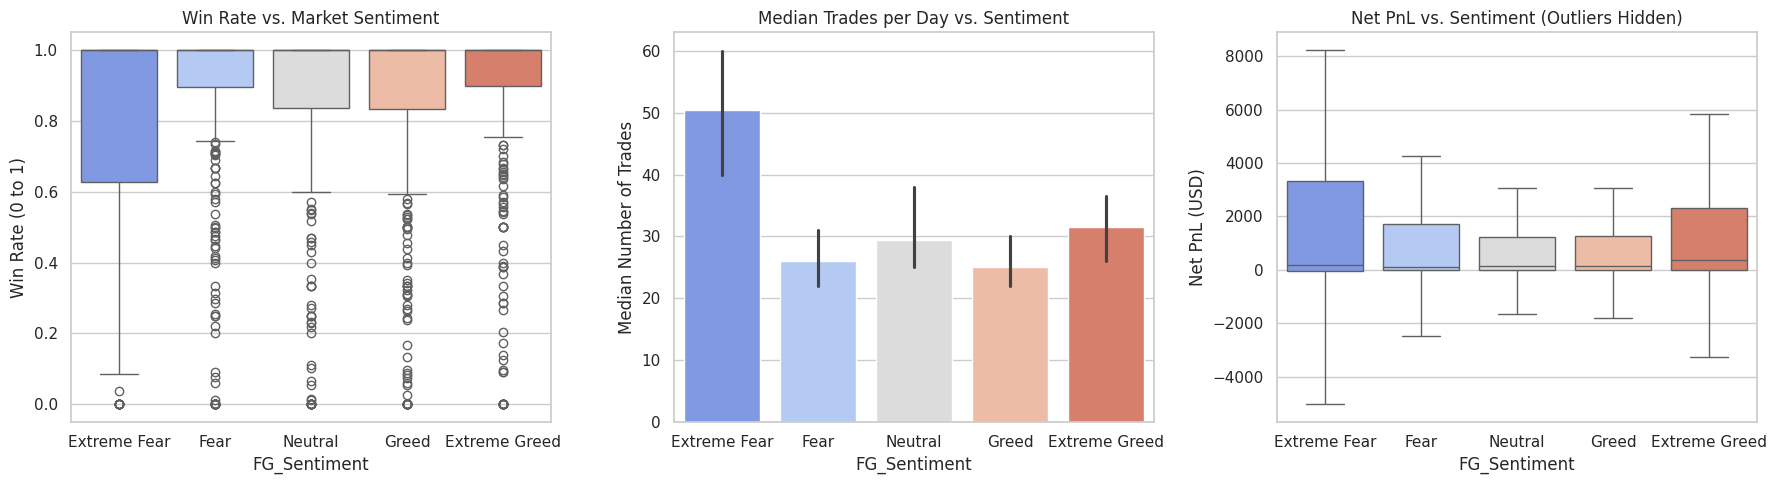

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Market Sentiment Summary
print("--- Market Sentiment vs. Trader Performance ---")

# Sort sentiments logically from Fear to Greed so our charts look nice
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
daily_metrics['FG_Sentiment'] = pd.Categorical(daily_metrics['FG_Sentiment'], categories=sentiment_order, ordered=True)

# Calculate key metrics grouped by Sentiment
sentiment_summary = daily_metrics.groupby('FG_Sentiment', observed=False).agg(
    Avg_Net_PnL=('Net_PnL', 'mean'),
    Median_Net_PnL=('Net_PnL', 'median'),
    Avg_Win_Rate=('Win_Rate', 'mean'),
    Median_Trades_Per_Day=('Total_Trades', 'median'),
    Total_Trader_Days=('Account', 'count')
).dropna(subset=['Total_Trader_Days']) # Drop any sentiments that didn't happen in our timeframe

print("\nSummary Table:")
print(sentiment_summary.round(2))

# 2. Visualizing the Impact of Sentiment
print("\nGenerating charts... (A window should pop up or appear below)")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Win Rate by Sentiment
sns.boxplot(data=daily_metrics, x='FG_Sentiment', y='Win_Rate', ax=axes[0], palette='coolwarm')
axes[0].set_title('Win Rate vs. Market Sentiment')
axes[0].set_ylabel('Win Rate (0 to 1)')

# Chart 2: Trade Frequency by Sentiment
sns.barplot(data=daily_metrics, x='FG_Sentiment', y='Total_Trades', estimator=np.median, ax=axes[1], palette='coolwarm')
axes[1].set_title('Median Trades per Day vs. Sentiment')
axes[1].set_ylabel('Median Number of Trades')

# Chart 3: Net PnL (Outliers hidden so we can actually see the boxes)
sns.boxplot(data=daily_metrics, x='FG_Sentiment', y='Net_PnL', ax=axes[2], palette='coolwarm', showfliers=False)
axes[2].set_title('Net PnL vs. Sentiment (Outliers Hidden)')
axes[2].set_ylabel('Net PnL (USD)')

plt.tight_layout()
plt.show()

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Clustering Traders into Behavioral Archetypes ---")

# 1. Aggregate data per trader (their lifetime stats in our dataset)
trader_profiles = daily_metrics.groupby('Account').agg(
    Lifetime_Trades=('Total_Trades', 'sum'),
    Avg_Daily_Win_Rate=('Win_Rate', 'mean'),
    Median_Trade_Size=('Avg_Trade_Size_USD', 'median'),
    Total_Net_PnL=('Net_PnL', 'sum')
).dropna()

# 2. Prepare data for clustering (scaling is crucial for K-Means)
# We will cluster based on behavior: Frequency, Win Rate, and Trade Size
features_to_cluster = ['Lifetime_Trades', 'Avg_Daily_Win_Rate', 'Median_Trade_Size']
scaler = StandardScaler()
scaled_features = scaler.fit_transform(trader_profiles[features_to_cluster])

# 3. Apply K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
trader_profiles['Cluster'] = kmeans.fit_predict(scaled_features)

# 4. Analyze the Clusters
cluster_summary = trader_profiles.groupby('Cluster').agg(
    Trader_Count=('Lifetime_Trades', 'count'),
    Avg_Lifetime_Trades=('Lifetime_Trades', 'mean'),
    Avg_Win_Rate=('Avg_Daily_Win_Rate', 'mean'),
    Median_Trade_Size=('Median_Trade_Size', 'median'),
    Median_Total_PnL=('Total_Net_PnL', 'median')
).round(2)

print("\nCluster Profiles Generated!")
print(cluster_summary)

Clustering Traders into Behavioral Archetypes ---

Cluster Profiles Generated!
         Trader_Count  Avg_Lifetime_Trades  Avg_Win_Rate  Median_Trade_Size  \
Cluster                                                                       
0                  10              2772.70          0.71            1924.32   
1                   4              7119.00          0.86           23664.70   
2                  18              8611.94          0.91            2474.84   

         Median_Total_PnL  
Cluster                    
0                67392.66  
1               516124.66  
2               116150.68  


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

print("Predictive Modeling (Next-Day Profitability) ---")

# 1. Create the Target Variable: "Next Day Profitable"
# We sort by Account and Date, then shift the Net PnL backwards by 1 to get tomorrow's PnL
model_df = daily_metrics.sort_values(by=['Account', 'date']).copy()
model_df['Next_Day_PnL'] = model_df.groupby('Account')['Net_PnL'].shift(-1)

# If Next Day PnL > 0, it's a 1 (Profitable), else 0 (Unprofitable)
model_df['Next_Day_Profitable'] = (model_df['Next_Day_PnL'] > 0).astype(int)

# Drop the last day for each trader (since we can't predict into a future we don't have)
# Also drop any rows where Win_Rate is NaN (days with only open positions)
model_df = model_df.dropna(subset=['Next_Day_PnL', 'Win_Rate'])

# 2. Select Features for Prediction
features = ['Total_Trades', 'Avg_Trade_Size_USD', 'Win_Rate', 'FG_Value', 'Net_PnL']
X = model_df[features]
y = model_df['Next_Day_Profitable']

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train the Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Evaluate the Model
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Unprofitable', 'Profitable']))

# 6. Feature Importance (What actually drives tomorrow's profits?)
importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance (What drives next-day profitability?):")
print(importances)

Predictive Modeling (Next-Day Profitability) ---

Model Accuracy: 68.17%

Classification Report:
              precision    recall  f1-score   support

Unprofitable       0.30      0.06      0.10        98
  Profitable       0.71      0.94      0.81       235

    accuracy                           0.68       333
   macro avg       0.50      0.50      0.45       333
weighted avg       0.59      0.68      0.60       333


Feature Importance (What drives next-day profitability?):
              Feature  Importance
4             Net_PnL    0.264470
1  Avg_Trade_Size_USD    0.205641
0        Total_Trades    0.195534
2            Win_Rate    0.193471
3            FG_Value    0.140885


In [8]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

print("--- Advanced Predictive Modeling: Tuning & Cross-Validation ---")

# 1. Prepare Data (Same setup as before)
model_df = daily_metrics.sort_values(by=['Account', 'date']).copy()
model_df['Next_Day_PnL'] = model_df.groupby('Account')['Net_PnL'].shift(-1)
model_df['Next_Day_Profitable'] = (model_df['Next_Day_PnL'] > 0).astype(int)
model_df = model_df.dropna(subset=['Next_Day_PnL', 'Win_Rate'])

features = ['Total_Trades', 'Avg_Trade_Size_USD', 'Win_Rate', 'FG_Value', 'Net_PnL']
X = model_df[features]
y = model_df['Next_Day_Profitable']

# Using stratify=y to ensure our 80/20 split maintains the same ratio of winners/losers
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Define Models and Parameter Grids
models = {
    'Random Forest': (RandomForestClassifier(random_state=42), {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 10, None],
        'min_samples_split': [2, 5, 10]
    }),
    'Gradient Boosting': (GradientBoostingClassifier(random_state=42), {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7]
    })
}

# 3. 5-Fold Stratified Cross Validation Setup
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_model_name = ""
best_overall_model = None
best_overall_score = 0

print("Running Grid Search with 5-Fold Cross Validation...\n")

for name, (model, params) in models.items():
    print(f"Tuning {name}...")
    # n_jobs=-1 uses all your computer's cores to speed this up
    grid = GridSearchCV(model, params, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)

    print(f"  Best params: {grid.best_params_}")
    print(f"  Best CV Accuracy: {grid.best_score_ * 100:.2f}%\n")

    # Keep track of the absolute best model overall
    if grid.best_score_ > best_overall_score:
        best_overall_score = grid.best_score_
        best_overall_model = grid.best_estimator_
        best_model_name = name

# 4. Final Evaluation on Hold-out Test Set
print(f"--- Final Evaluation using the Best Model: {best_model_name} ---")
y_pred = best_overall_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Hold-out Test Accuracy: {test_accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Unprofitable', 'Profitable']))

# 5. Feature Importance for Best Model
importances = pd.DataFrame({
    'Feature': features,
    'Importance': best_overall_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(importances)

--- Advanced Predictive Modeling: Tuning & Cross-Validation ---
Running Grid Search with 5-Fold Cross Validation...

Tuning Random Forest...
  Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
  Best CV Accuracy: 70.03%

Tuning Gradient Boosting...
  Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
  Best CV Accuracy: 70.40%

--- Final Evaluation using the Best Model: Gradient Boosting ---
Hold-out Test Accuracy: 69.37%

Classification Report:
              precision    recall  f1-score   support

Unprofitable       0.54      0.14      0.23       104
  Profitable       0.71      0.94      0.81       229

    accuracy                           0.69       333
   macro avg       0.62      0.54      0.52       333
weighted avg       0.65      0.69      0.63       333


Feature Importance:
              Feature  Importance
1  Avg_Trade_Size_USD    0.281759
0        Total_Trades    0.257152
4             Net_PnL    0.228143
3            FG_Val